In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [3]:
#TRACKED TRAJECTORY ENTRAINMENT/DETRAINMENT
################################################################

In [4]:
# if 'lfc_data' not in globals():
#     lfc_data = data['lfc'].data
# def mean_LFC(out_nz):
    
        
#     import numpy as np
#     import itertools
    
#     # Assuming out_nz, Y, X, and lfc_data are defined
#     all_lfc_values = []  # List to store all results
    
#     # Loop over each row in out_nz
#     for ind, row in enumerate(out_nz):
#         ts = np.arange(row[4], row[5] + 1)  # Create the range for time indices
#         ys = Y[ts, row[0]]  # y indices
#         xs = X[ts, row[0]]  # x indices
        
#         # Generate tuples for element-wise indexing
#         index_tuples = list(itertools.zip_longest(ts, ys, xs, fillvalue=None))
        
#         # Collect lfc_data values for the current row
#         lfc_values = [lfc_data[t, y, x] for t, y, x in index_tuples]
        
#         # Append to the list
#         all_lfc_values.append(lfc_values)
    
#     all_lfc_values=[value for row_values in all_lfc_values for value in row_values]
    
#     mean_cloudbase=np.mean(all_lfc_values)/1000
#     return mean_cloudbase
# # mean_LFC(ALL_out_nz)
# # mean_LFC(SHALLOW_out_nz)
# # mean_LFC(DEEP_out_nz)

# # mean_LFC(save_nz)
# # mean_LFC(SHALLOW_save_nz)
# # mean_LFC(DEEP_save_nz)

# # mean_LFC(ALL_SBZ_out_nz)
# # mean_LFC(SHALLOW_SBZ_out_nz)
# # mean_LFC(DEEP_SBZ_out_nz)

# # mean_LFC(ALL_nonSBZ_out_nz)
# # mean_LFC(SHALLOW_nonSBZ_out_nz)
# # mean_LFC(DEEP_nonSBZ_out_nz)

In [3]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/job_array/'
with h5py.File(dir2+'lagrangian_binary_array.h5', 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [4]:
#######################################################
#READING BACK IN 
dir3=dir+'Project_Algorithms/Entrainment/3D_entrainment_profiles.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_e_g = h5f["profile_array_e_g"][:]
    profile_array_e_c = h5f["profile_array_e_c"][:]
dir3=dir+'Project_Algorithms/Entrainment/3D_detrainment_profiles.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_d_g = -h5f["profile_array_d_g"][:]
    profile_array_d_c = -h5f["profile_array_d_c"][:]

In [35]:
#READING BACK IN
mins_thresh=5
# mins_thresh=10
dir3=dir+'Project_Algorithms/Entrainment/processed_binary_arrays_'+str(mins_thresh)+'mins.h5'
with h5py.File(dir3, 'r') as h5file:
    A_g_Processed_e = h5file['A_g_Processed_e'][:]
    A_g_Processed_d = h5file['A_g_Processed_d'][:]
    A_c_Processed_e = h5file['A_c_Processed_e'][:]
    A_c_Processed_d = h5file['A_c_Processed_d'][:]

In [ ]:
#FUNCTIONS
#######################

In [33]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=data['xf'][-1].item()-data['xf'][0].item() #x length (km)
Ly=data['yf'][-1].item()-data['yf'][0].item() #y length (km)
Np=len(parcel['xh']) #number of lagrangian parcles
dt=data['time'][1].item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out
rho_data=data['rho'].data
def rho(x,y,z,t):
    # out=data['rho'].isel(xh=x,yh=y,zh=z,time=t).item()
    out=rho_data[t,z,y,x]
    return out
def m(t):
    m=0
    #triple sum
    for k in range(len('zh')):
        for j in range(len('yh')):
            for i in range(len('xh')):
                rho_out=rho(i,j,k,t)
                m+=rho_out*(zf(k+1)-zf(k))
    #triple sum
    m=m*dx*dy/Np
    out=m
    return out

In [34]:
def ed3d(A,t,z,y,x,type):
    #Get Z Locations
    zs=Z[t,:]
    ys=Y[t,:]
    xs=X[t,:]
    
    #Essential A_t-A_(t-1)
    D=A[t,:]-A[t-1,:]
    
    #Essentially the I function
    zyx_ind=np.where((zs==z)&(ys==y)&(xs==x))
    A_z=D[zyx_ind]
    
    #Esentially the H function

    if type=='e':
        A_z[A_z<0]=0 #entrainment
    if type=='d':
        A_z[A_z>0]=0 #detrainment

    #Essentially the sumnation
    A_sum=np.sum(A_z)

    # if type=='d': 
    #     A_sum*=-1

    #CONSTANT
    ############
    m_out=m(t)
    dz=zf(z+1)-zf(z);dy=1000;dx=1000
    constant=(m_out/dx/dy/dz/dt) 
    # constant=1
    A_sum*=constant
    return A_sum

In [ ]:
#####################################################

In [6]:
#DOMAIN SUBSETTING
def DOMAIN_SUBSET(out_nz):
    print(f'length before: {len(out_nz)}')
    
    where_coast_xh=np.where(data['xh']>=0)[0][0]
    where_coast_xf=np.where(data['xf']>=0)[0][0]
    end_xh=len(data['xh'])-1-50
    end_xf=len(data['xf'])-1-50
    print(f'x in {0}:{where_coast_xh-1} FOR SEA')
    print(f'x in {where_coast_xh}:{end_xh} FOR LAND')
    # 6:30==>12*6+6=78
    t_end=78
    print(f't in {0}:{t_end} (6.5 hours)')
    #SUBSETTING CODE
    # OCEAN=data.isel(time=slice(0,78+1),xh=slice(0,where_coast_xh+1),xf=slice(0,where_coast_xf+1))
    # LAND=data.isel(time=slice(0,78+1),xh=slice(where_coast_xh,end_xh+1),xf=slice(where_coast_xf,end_xf+1)); data=LAND.copy()
    
    xs=X[list(out_nz[:,4]),list(out_nz[:,0])]
    
    out_nz=out_nz[np.where((xs>=where_coast_xh)&(xs<=end_xh))]
    out_nz=out_nz[np.where(out_nz[:,4]<=t_end)]

    print(f'length after: {len(out_nz)}')
    return out_nz

In [7]:
#OUT_NZ

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***


out=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
save=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_nz[:,0] == elem)[0] 
    extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
out_nz=out_nz[mask]; 
###############################################################################

out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
placeholder=out_nz.copy(); run=True
print(f'there are a total of {len(out_nz)} CL parcels and {len(save_nz)} nonCL parcels')
############################################################
#SUBSETTING
subset=True
if subset==True:
    out_nz=DOMAIN_SUBSET(out_nz)
    save_nz=DOMAIN_SUBSET(save_nz)
############################################################

ALL_out_nz=out_nz.copy(); ALL_save_nz=save_nz.copy()

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
list of first 10 ignored parcels
[[34 302 76 0.7418956298828125 34 37]
 [246 338 77 0.33685012817382814 2 11]
 [365 357 3 0.658669677734375 115 121]
 [363 440 62 0.18019241333007813 6 14]
 [483 465 43 0.2835696716308594 27 33]]
there are a total of 2088 CL parcels and 1717 nonCL parcels
length before: 2088
x in 0:255 FOR SEA
x in 256:461 FOR LAND
t in 0:78 (6.5 hours)
length after: 

In [8]:
#SHALLOW

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def SHALLOW_threshold(zthresh,type):

    if type=='CL':
        out_nz=ALL_out_nz.copy()
    if type=='nonCL':
        out_nz=ALL_save_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)
##############################################################

convectivelevel=4 #4km
SHALLOW_out_nz=SHALLOW_threshold(convectivelevel,type='CL')
SHALLOW_save_nz=SHALLOW_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(SHALLOW_out_nz)} CL parcels and {len(SHALLOW_save_nz)} nonCL parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]
 [885 300 10 0.11673685455322266 59 65]]
there are a total of 1139 CL parcels and 577 nonCL parcels


In [9]:
#DEEP

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def DEEP_threshold(zthresh,type):
    if type=='CL':
        out_nz=ALL_out_nz.copy()
    if type=='nonCL':
        out_nz=ALL_save_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)
##############################################################

convectivelevel=6 #4km
DEEP_out_nz=DEEP_threshold(convectivelevel,type='CL')
DEEP_save_nz=DEEP_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(DEEP_out_nz)} CL parcels and {len(DEEP_save_nz)} nonCL parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]
 [885 300 10 0.11673685455322266 59 65]]
there are a total of 362 CL parcels and 139 nonCL parcels


In [10]:
#FINDING MEAN CLOUD BASE
zh=data['zh'].values
w_thresh2=0.5
qcqi_thresh=1e-6
type='all'

if 'emptylike' not in globals():
    print('loading neccessary variables')
    # variable='w'; w_data=data[variable] #get w data
    # w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    emptylike=True
    print('done')

if type=='all':
    out_nz=ALL_out_nz.copy()
if type=='deep':
    out_nz=DEEP_out_nz.copy()
if type=='shallow':
    out_nz=SHALLOW_out_nz.copy()

zhs=data['zh'].values
profile_array =np.zeros((len(zhs), 2)) #column 1: var, column 2: counter, column 3: list of zhs
profile_array[:,1]=zhs;

# cloudbase_lst=[]
after=4 #20 minutes
for row in range(out_nz.shape[0]):
    p=out_nz[row,0]
    
    # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
    ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
    ts = np.arange(out_nz[row, 4], ts_end)
    
    zs=Z[ts,p]
    ys=Y[ts,p]
    xs=X[ts,p]
    for t, z, y, x in zip(ts, zs, ys, xs):
        # var1=w_data[t,z,y,x]
        var2=qc_plus_qi[t,z,y,x]

        if (var2>=qcqi_thresh):
        # if (var1>=w_thresh2) & (var2>=qcqi_thresh):
            profile_array[z,0]+=1
            # cloudbase_lst.append(zh[z])
            break

# print(np.mean(cloudbase_lst))
# print(np.min(cloudbase_lst))
# plt.hist(cloudbase_lst,bins=40,orientation='horizontal');
all_cloudbase=zh[np.where(profile_array[:,0]!=0)[0][0]]
print(all_cloudbase)

loading neccessary variables
done
1.5475868


In [60]:
#MAKING ENTRAINMENT PROFILE ARRAY
type2='general'
type2='cloudy'

if type2=='general':
    # A_e=A_g; A_d=A_e #COMMENT OUT IF USING PRECALCULATED DATA
    # A_e=A_g_Processed_e #CALCULATE WITH PREPROCESSING
    # A_d=A_g_Processed_d #CALCULATE WITH PREPROCESSING
    
    profile_array_e=profile_array_e_g #PRECALCULATED
    profile_array_d=profile_array_d_g #PRECALCULATED
if type2=='cloudy':
    # A=A_c #COMMENT OUT IF USING PRECALCULATED DATA
    # A_e=A_c_Processed_e #CALCULATE WITH PREPROCESSING
    # A_d=A_c_Processed_d #CALCULATE WITH PREPROCESSING
    
    profile_array_e=profile_array_e_c #PRECALCULATED
    profile_array_d=profile_array_d_c #PRECALCULATED


after=4 #20 minutes

zhs=data['zh'].values
ALL_profile_array_e=np.zeros((len(zhs), 2)) #column 1: var, column 2: counter, column 3: list of zhs
ALL_profile_array_d=ALL_profile_array_e.copy()
ALL_profile_array_e[:,1]=zhs;ALL_profile_array_d[:,1]=zhs

for row in range(out_nz.shape[0]):
    p=out_nz[row,0]
    
    # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
    ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
    ts = np.arange(out_nz[row, 4], ts_end)
    
    zs=Z[ts,p]
    ys=Y[ts,p]
    xs=X[ts,p]
    for t, z, y, x in zip(ts, zs, ys, xs):
        # e=ed3d(A_e,t,z,y,x,type='e') #COMMENT OUT IF USING PRECALCULATED DATA
        # d=ed3d(A_d,t,z,y,x,type='d') #COMMENT OUT IF USING PRECALCULATED DATA
        
        e=profile_array_e[t,z,y,x] #PRECALCULATED
        d=profile_array_d[t,z,y,x] #PRECALCULATED
        ALL_profile_array_e[z,0]+=e
        ALL_profile_array_d[z,0]+=d

print('done')

done


In [61]:
#MAKING PROFILE ARRAY
type2='general'
type2='cloudy'

if type2=='general':
    # A_e=A_g; A_d=A_e #COMMENT OUT IF USING PRECALCULATED DATA
    # A_e=A_g_Processed_e #CALCULATE WITH PREPROCESSING
    # A_d=A_g_Processed_d #CALCULATE WITH PREPROCESSING
    
    profile_array_e=profile_array_e_g #PRECALCULATED
    profile_array_d=profile_array_d_g #PRECALCULATED
if type2=='cloudy':
    # A=A_c #COMMENT OUT IF USING PRECALCULATED DATA
    # A_e=A_c_Processed_e #CALCULATE WITH PREPROCESSING
    # A_d=A_c_Processed_d #CALCULATE WITH PREPROCESSING
    
    profile_array_e=profile_array_e_c #PRECALCULATED
    profile_array_d=profile_array_d_c #PRECALCULATED
    
zhs=data['zh'].values
SHALLOW_profile_array_e=np.zeros((len(zhs), 2)) #column 1: var, column 2: counter, column 3: list of zhs
SHALLOW_profile_array_d=SHALLOW_profile_array_e.copy()
SHALLOW_profile_array_e[:,1]=zhs;SHALLOW_profile_array_d[:,1]=zhs

after=4 #20 minutes
# after=0

for row in range(SHALLOW_out_nz.shape[0]):
    p=SHALLOW_out_nz[row,0]
    
    # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
    ts_end = min(SHALLOW_out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
    ts = np.arange(SHALLOW_out_nz[row, 4], ts_end)
    
    zs=Z[ts,p]
    ys=Y[ts,p]
    xs=X[ts,p]
    for t, z, y, x in zip(ts, zs, ys, xs):
        # e=ed3d(A_e,t,z,y,x,type='e') #COMMENT OUT IF USING PRECALCULATED DATA
        # d=ed3d(A_d,t,z,y,x,type='d') #COMMENT OUT IF USING PRECALCULATED DATA
        
        e=profile_array_e[t,z,y,x] #PRECALCULATED
        d=profile_array_d[t,z,y,x] #PRECALCULATED
        SHALLOW_profile_array_e[z,0]+=e
        SHALLOW_profile_array_d[z,0]+=d

print('done')

done


In [62]:
#MAKING PROFILE ARRAY

type2='general'
type2='cloudy'

if type2=='general':
    # A_e=A_g; A_d=A_e #COMMENT OUT IF USING PRECALCULATED DATA
    # A_e=A_g_Processed_e #CALCULATE WITH PREPROCESSING
    # A_d=A_g_Processed_d #CALCULATE WITH PREPROCESSING
    
    profile_array_e=profile_array_e_g #PRECALCULATED
    profile_array_d=profile_array_d_g #PRECALCULATED
if type2=='cloudy':
    # A=A_c #COMMENT OUT IF USING PRECALCULATED DATA
    # A_e=A_c_Processed_e #CALCULATE WITH PREPROCESSING
    # A_d=A_c_Processed_d #CALCULATE WITH PREPROCESSING
    
    profile_array_e=profile_array_e_c #PRECALCULATED
    profile_array_d=profile_array_d_c #PRECALCULATED
    
zhs=data['zh'].values
DEEP_profile_array_e=np.zeros((len(zhs), 2)) #column 1: var, column 2: counter, column 3: list of zhs
DEEP_profile_array_d=DEEP_profile_array_e.copy()
DEEP_profile_array_e[:,1]=zhs;DEEP_profile_array_d[:,1]=zhs

after=4 #20 minutes
# after=0

for row in range(DEEP_out_nz.shape[0]):
    p=DEEP_out_nz[row,0]
    
    # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
    ts_end = min(DEEP_out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
    ts = np.arange(DEEP_out_nz[row, 4], ts_end)
    
    zs=Z[ts,p]
    ys=Y[ts,p]
    xs=X[ts,p]
    for t, z, y, x in zip(ts, zs, ys, xs):
        # e=ed3d(A_e,t,z,y,x,type='e') #COMMENT OUT IF USING PRECALCULATED DATA
        # d=ed3d(A_e,t,z,y,x,type='d') #COMMENT OUT IF USING PRECALCULATED DATA
        
        e=profile_array_e[t,z,y,x] #PRECALCULATED
        d=profile_array_d[t,z,y,x] #PRECALCULATED
        DEEP_profile_array_e[z,0]+=e
        DEEP_profile_array_d[z,0]+=d

print('done')

done


Text(0.5, 0.98, 'Entrainment and Detrainment')

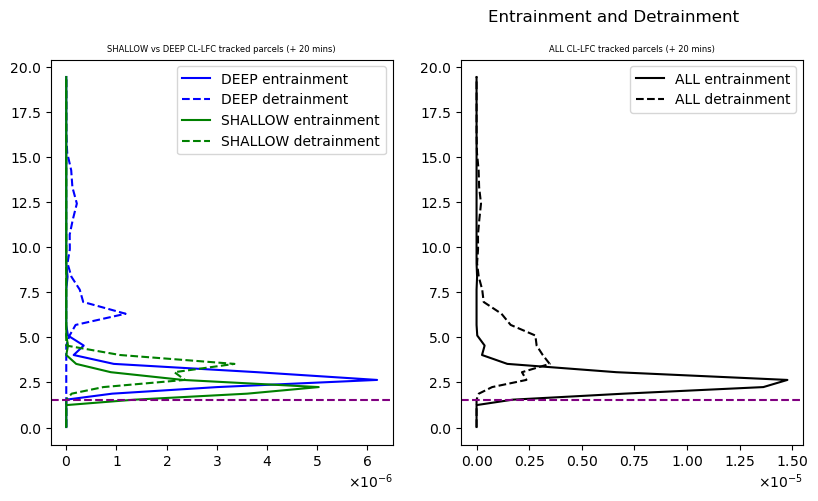

In [63]:
fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(1, 3, figure=fig)

# First subplot (left side) for DEEP vs SHALLOW
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(DEEP_profile_array_e[:, 0], DEEP_profile_array_e[:, 1], label='DEEP entrainment', color='blue')
ax1.plot(DEEP_profile_array_d[:, 0]*-1, DEEP_profile_array_d[:, 1], label='DEEP detrainment', color='blue',linestyle='dashed')
ax1.plot(SHALLOW_profile_array_e[:, 0], SHALLOW_profile_array_e[:, 1], label='SHALLOW entrainment', color='green')
ax1.plot(SHALLOW_profile_array_d[:, 0]*-1, SHALLOW_profile_array_d[:, 1], label='SHALLOW detrainment', color='green', linestyle='dashed')
ax1.set_title('SHALLOW vs DEEP CL-LFC tracked parcels (+ 20 mins)',fontsize=6)
ax1.legend()

# Second subplot (right side) for ALL
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(ALL_profile_array_e[:, 0], ALL_profile_array_e[:, 1], color='k', label='ALL entrainment')
ax2.plot(ALL_profile_array_d[:, 0]*-1, ALL_profile_array_d[:, 1], color='k', label='ALL detrainment',linestyle='dashed')
ax2.set_title('ALL CL-LFC tracked parcels (+ 20 mins)',fontsize=6)
ax2.legend()


#ADD ALL,SHALLOW,DEEP nonCL parcels
# ax3 = fig.add_subplot(gs[0, 1])
# ax3.plot(nonCL_profile_array_e[:, 0], nonCL_profile_array_e[:, 1], label='entrainment')
# ax3.plot(nonCL_profile_array_d[:, 0], nonCL_profile_array_d[:, 1], label='detrainment')
# ax3.set_title('ALL nonCL CL-LFC tracked parcels')
# ax3.legend()

# #Mean LFC
# ax1.axhline(np.mean((mean_LFC(SHALLOW_out_nz),
#                       mean_LFC(DEEP_out_nz))),color='blue',linestyle='dashed')

# ax2.axhline(mean_LFC(ALL_out_nz),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
for axis in [ax1,ax2]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2])

fig.suptitle('Entrainment and Detrainment') #**********

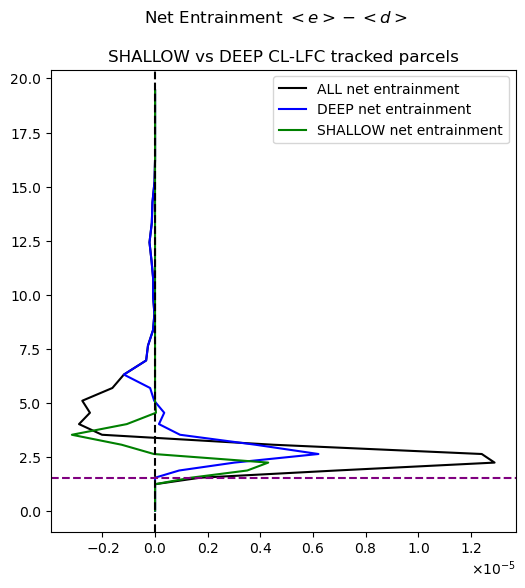

In [64]:
#NET ENTRAINMENT

fig = plt.figure(figsize=(6, 6))
fig.suptitle(r'Net Entrainment $<e>-<d>$')
gs = gridspec.GridSpec(1, 1, figure=fig)


# First subplot (left side) for DEEP vs SHALLOW
ax1 = fig.add_subplot(gs[0, 0])

plotting_data=ALL_profile_array_e[:, 0]-ALL_profile_array_d[:, 0]*-1
ax1.plot(plotting_data, ALL_profile_array_e[:, 1], color='black',label='ALL net entrainment')
plotting_data=DEEP_profile_array_e[:, 0]-DEEP_profile_array_d[:, 0]*-1
ax1.plot(plotting_data, DEEP_profile_array_e[:, 1], label='DEEP net entrainment', color='blue')
plotting_data=SHALLOW_profile_array_e[:, 0]-SHALLOW_profile_array_d[:, 0]*-1
ax1.plot(plotting_data, SHALLOW_profile_array_e[:, 1], label='SHALLOW net entrainment', color='green')

plt.axvline(0,color='black',linestyle='dashed')
ax1.set_title('SHALLOW vs DEEP CL-LFC tracked parcels')
ax1.legend()


ax2.set_title('ALL CL-LFC tracked parcels')
ax2.legend()


#ADD ALL,SHALLOW,DEEP nonCL parcels
# ax3 = fig.add_subplot(gs[0, 1])
# ax3.plot(nonCL_profile_array_e[:, 0], nonCL_profile_array_e[:, 1], label='entrainment')
# ax3.plot(nonCL_profile_array_d[:, 0], nonCL_profile_array_d[:, 1], label='detrainment')
# ax3.set_title('ALL nonCL CL-LFC tracked parcels')
# ax3.legend()




# #Mean LFC
# ax1.axhline(np.mean((mean_LFC(ALL_out_nz),mean_LFC(SHALLOW_out_nz),
#                       mean_LFC(DEEP_out_nz))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
for axis in [ax1,ax2]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2])

In [15]:
######

In [65]:
#CL vs nonCL 
#MAKING PROFILE ARRAY

type2='general'
# type2='cloudy'

if type2=='general':
    # A_e=A_g; A_d=A_e #COMMENT OUT IF USING PRECALCULATED DATA
    # A_e=A_g_Processed_e #CALCULATE WITH PREPROCESSING
    # A_d=A_g_Processed_d #CALCULATE WITH PREPROCESSING
    
    profile_array_e=profile_array_e_g #PRECALCULATED
    profile_array_d=profile_array_d_g #PRECALCULATED
if type2=='cloudy':
    # A=A_c #COMMENT OUT IF USING PRECALCULATED DATA
    # A_e=A_c_Processed_e #CALCULATE WITH PREPROCESSING
    # A_d=A_c_Processed_d #CALCULATE WITH PREPROCESSING
    
    profile_array_e=profile_array_e_c #PRECALCULATED
    profile_array_d=profile_array_d_c #PRECALCULATED

def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

def CL_tracked_ed_profile(type,edtype):
    after=4 #20 minutes
    # after=0

    if type=='all':
        out_nz=ALL_out_nz.copy()
    if type=='shallow':
        out_nz=SHALLOW_out_nz.copy()
    if type=='deep':
        out_nz=DEEP_out_nz.copy()
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_nz.shape[0]):
        p=out_nz[row,0]
        
        # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
        ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_nz[row, 4], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        for t, z, y, x in zip(ts, zs, ys, xs):      
            if edtype=='e':
                # var=ed3d(A_e,t,z,y,x,type='e') #COMMENT OUT IF USING PRECALCULATED DATA
                var=profile_array_e[t,z,y,x] #PRECALCULATED
            elif edtype=='d':
                # var=ed3d(A_d,t,z,y,x,type='d') #COMMENT OUT IF USING PRECALCULATED DATA
                var=profile_array_d[t,z,y,x] #PRECALCULATED
                
            profile_array[z,0]+=var;profile_array[z,1]+=1
    return profile_array

print('all')
ALL_e=CL_tracked_ed_profile('all','e')
ALL_d=CL_tracked_ed_profile('all','d')
print('shallow')
SHALLOW_e=CL_tracked_ed_profile('shallow','e')
SHALLOW_d=CL_tracked_ed_profile('shallow','d')
print('deep')
DEEP_e=CL_tracked_ed_profile('deep','e')
DEEP_d=CL_tracked_ed_profile('deep','d')

all
shallow
deep


In [66]:
#CL vs nonCL #**********
#MAKING PROFILE ARRAY
type2='general'
# type2='cloudy'

if type2=='general':
    # A_e=A_g; A_d=A_e #COMMENT OUT IF USING PRECALCULATED DATA
    # A_e=A_g_Processed_e #CALCULATE WITH PREPROCESSING
    # A_d=A_g_Processed_d #CALCULATE WITH PREPROCESSING
    
    profile_array_e=profile_array_e_g #PRECALCULATED
    profile_array_d=profile_array_d_g #PRECALCULATED
if type2=='cloudy':
    # A=A_c #COMMENT OUT IF USING PRECALCULATED DATA
    # A_e=A_c_Processed_e #CALCULATE WITH PREPROCESSING
    # A_d=A_c_Processed_d #CALCULATE WITH PREPROCESSING
    
    profile_array_e=profile_array_e_c #PRECALCULATED
    profile_array_d=profile_array_d_c #PRECALCULATED

def nonCL_tracked_ed_profile(type,edtype):
    after=4 #20 minutes
    # after=0

    if type=='all':
        out_nz=ALL_save_nz.copy()
    if type=='shallow':
        out_nz=SHALLOW_save_nz.copy()
    if type=='deep':
        out_nz=DEEP_save_nz.copy()

    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_nz.shape[0]):
        p=out_nz[row,0]
        
        # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
        ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_nz[row, 4], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        for t, z, y, x in zip(ts, zs, ys, xs):
            if edtype=='e':
                # var=ed3d(A_e,t,z,y,x,type='e') #COMMENT OUT IF USING PRECALCULATED DATA
                var=profile_array_e[t,z,y,x] #PRECALCULATED
            elif edtype=='d':
                # var=ed3d(A_d,t,z,y,x,type='d') #COMMENT OUT IF USING PRECALCULATED DATA
                var=profile_array_d[t,z,y,x] #PRECALCULATED
                
            profile_array[z,0]+=var;profile_array[z,1]+=1
    return profile_array

print('all')
nonCL_ALL_e=nonCL_tracked_ed_profile('all','e')
nonCL_ALL_d=nonCL_tracked_ed_profile('all','d')
print('shallow')
nonCL_SHALLOW_e=nonCL_tracked_ed_profile('shallow','e')
nonCL_SHALLOW_d=nonCL_tracked_ed_profile('shallow','d')
print('deep')
nonCL_DEEP_e=nonCL_tracked_ed_profile('deep','e')
nonCL_DEEP_d=nonCL_tracked_ed_profile('deep','d')

all
shallow
deep


(-5.369675250220041e-06, 0.00011276318025462086)
(-0.9395961281843483, 20.41351872170344)


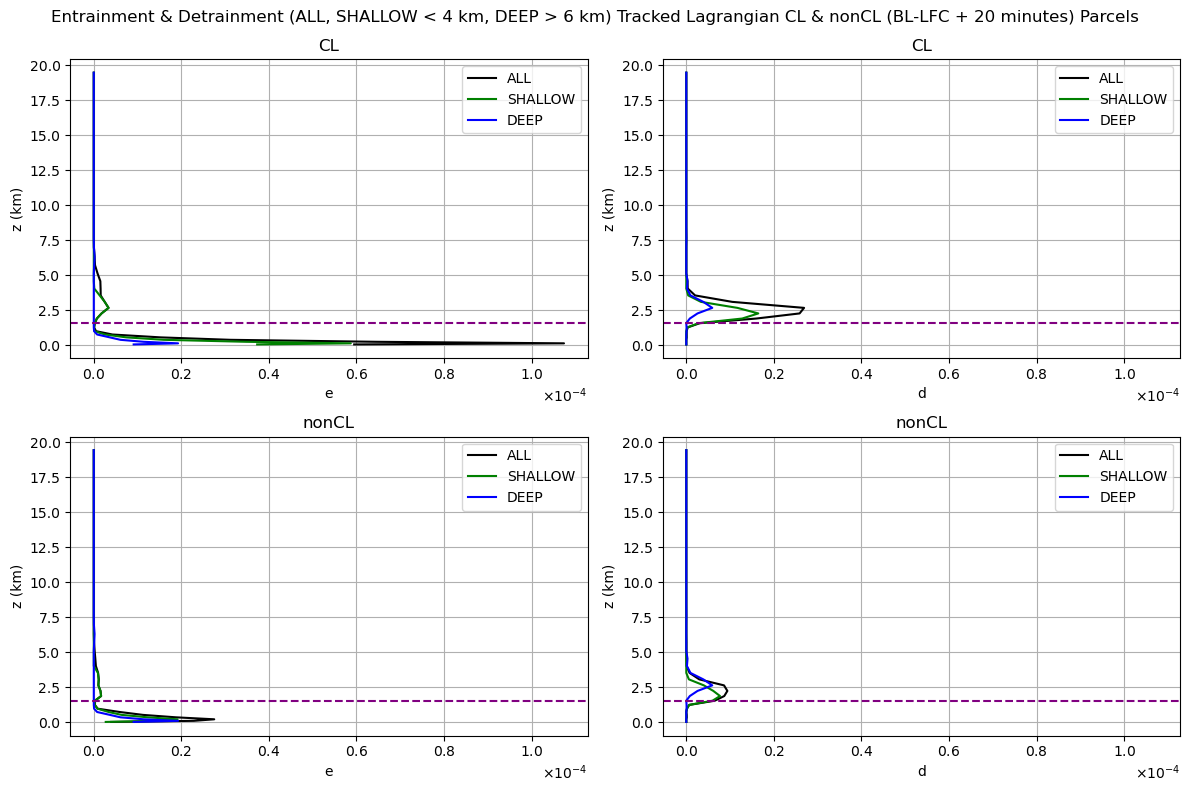

In [67]:
xlims=[] #FIXING XAXIS
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

#MAKING DETRAINMENT VALUES POSITIVE
ALL_d[:,0]*=-1;SHALLOW_d[:,0]*=-1;DEEP_d[:,0]*=-1
nonCL_ALL_d[:,0]*=-1;nonCL_SHALLOW_d[:,0]*=-1;nonCL_DEEP_d[:,0]*=-1

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (ALL_e, SHALLOW_e, DEEP_e, 'e', 'CL'),
    (ALL_d, SHALLOW_d, DEEP_d, 'd', 'CL'),
    (nonCL_ALL_e, nonCL_SHALLOW_e, DEEP_e, 'e', 'nonCL'),
    (nonCL_ALL_d, nonCL_SHALLOW_d, DEEP_d, 'd', 'nonCL'),
]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])
    
    # # Compute the averaged profile
    # ALL_profile = averaged_profiles(ALL_profile_array)
    # SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    # DEEP_profile = averaged_profiles(DEEP_profile_array)
    ALL_profile=ALL_profile_array.copy()
    SHALLOW_profile=SHALLOW_profile_array.copy()
    DEEP_profile=DEEP_profile_array.copy()
    
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, -1],color='black',label='ALL')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1],color='green',label='SHALLOW')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1],color='blue',label='DEEP')
    ax.set_xlabel(xlabel)
    ax.set_title(CLlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)
    

    #LEGEND
    ax.legend()
    # legend_ax = fig.add_subplot(gs[0, 2])  # Use the (2, 3) grid slot for the legend
    # legend_ax.axis("off")  # Hide axes for the legend box
    # legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

axs = fig.get_axes()
ax1,ax2,ax3,ax4=axs
fix_x_limits([ax1,ax2,ax3,ax4])
fix_y_limits([ax1,ax2,ax3,ax4])

#ACCESSORIES
plt.suptitle('Entrainment & Detrainment (ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian CL & nonCL (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()


# #Mean LFC
# axs = fig.get_axes()
# ax1, ax2, ax3, ax4 = axs
# for axis in [ax1,ax2]:
#     axis.axhline(np.mean((mean_LFC(ALL_out_nz),mean_LFC(SHALLOW_out_nz),
#                           mean_LFC(DEEP_out_nz))),color='blue',linestyle='dashed',linewidth=1.2)
# for axis in [ax3,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_save_nz),mean_LFC(SHALLOW_save_nz),
#                           mean_LFC(DEEP_save_nz))),color='blue',linestyle='dashed',linewidth=1.2)

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4= axs
for axis in [ax1,ax2,ax3,ax4]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3,ax4])

(-3.067497294601176e-05, 0.00011396819443061094)
(-0.9395961281843483, 20.41351872170344)


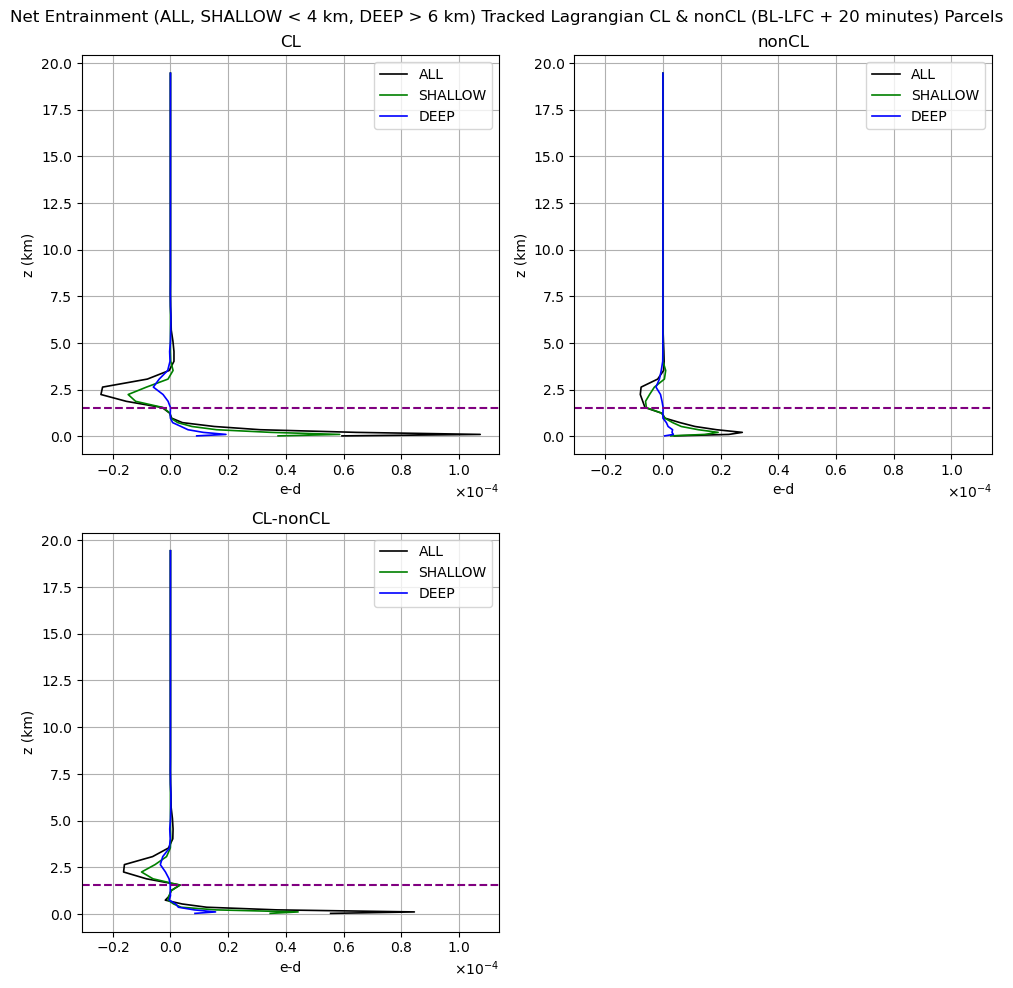

In [69]:
#NET ENTRAINMENT

xlims=[] #FIXING XAXIS
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# List of profile arrays and their corresponding labels and x-axis titles

ALL_net=ALL_e.copy(); ALL_net[:,0]-=ALL_d[:,0]
SHALLOW_net=SHALLOW_e.copy(); SHALLOW_net[:,0]-=SHALLOW_d[:,0]
DEEP_net=DEEP_e.copy(); DEEP_net[:,0]-=DEEP_d[:,0]

nonCL_ALL_net=nonCL_ALL_e.copy(); nonCL_ALL_net[:,0]-=nonCL_ALL_d[:,0]
nonCL_SHALLOW_net=nonCL_SHALLOW_e.copy(); nonCL_SHALLOW_net[:,0]-=nonCL_SHALLOW_d[:,0]
nonCL_DEEP_net=nonCL_DEEP_e.copy(); nonCL_DEEP_net[:,0]-=nonCL_DEEP_d[:,0]

ALL_CLnonCL=ALL_net.copy(); ALL_CLnonCL[:,0]-=nonCL_ALL_net[:,0]
SHALLOW_CLnonCL=SHALLOW_net.copy(); SHALLOW_CLnonCL[:,0]-=nonCL_SHALLOW_net[:,0]
DEEP_CLnonCL=DEEP_net.copy(); DEEP_CLnonCL[:,0]-=nonCL_DEEP_net[:,0]


profiles = [
    (ALL_net, SHALLOW_net, DEEP_net, 'e-d', 'CL'),
    (nonCL_ALL_net, nonCL_SHALLOW_net, nonCL_DEEP_net, 'e-d', 'nonCL'),
    (ALL_CLnonCL, SHALLOW_CLnonCL, DEEP_CLnonCL, 'e-d', 'CL-nonCL')
]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Loop through the profiles and plot them on subplots
axes = {}
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
    globals()[f'ax{i+1}'] = fig.add_subplot(gs[i])  # Dynamically create ax1, ax2, ax3, ...
    ax = globals()[f'ax{i+1}']

    
    # # Compute the averaged profile
    # ALL_profile = averaged_profiles(ALL_profile_array)
    # SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    # DEEP_profile = averaged_profiles(DEEP_profile_array)
    ALL_profile=ALL_profile_array.copy()
    SHALLOW_profile=SHALLOW_profile_array.copy()
    DEEP_profile=DEEP_profile_array.copy()
    
    
    # Plot the profile

    #linewidth
    if i == 2: 
        lw=1.2
    else: lw=1.2
        
    ax.plot(ALL_profile[:, 0], ALL_profile[:, -1],color='black',label='ALL',lw=lw)
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1],color='green',label='SHALLOW',lw=lw)
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1],color='blue',label='DEEP',lw=lw)
    ax.set_xlabel(xlabel)
    ax.set_title(CLlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    # ax.set_ylim(0,10)
    
#LEGEND
    ax.legend()
# legend_ax = fig.add_subplot(gs[0, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

axs = fig.get_axes(); ax1,ax2,ax3=axs
fix_x_limits([ax1,ax2,ax3])
fix_y_limits([ax1,ax2,ax3])

#ACCESSORIES
plt.suptitle('Net Entrainment (ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian CL & nonCL (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #Mean LFC
# axs = fig.get_axes()
# ax1, ax2, ax3 = axs
# for axis in [ax1]:
#     axis.axhline(np.mean((mean_LFC(ALL_out_nz),mean_LFC(SHALLOW_out_nz),
#                           mean_LFC(DEEP_out_nz))),color='blue',linestyle='dashed',linewidth=1.2)
# for axis in [ax2]:
#     axis.axhline(np.mean((mean_LFC(ALL_save_nz),mean_LFC(SHALLOW_save_nz),
#                           mean_LFC(DEEP_save_nz))),color='blue',linestyle='dashed',linewidth=1.2)
# for axis in [ax3]:
#     axis.axhline(np.mean((mean_LFC(ALL_out_nz),mean_LFC(SHALLOW_out_nz),
#                           mean_LFC(DEEP_out_nz),mean_LFC(ALL_save_nz),mean_LFC(SHALLOW_save_nz),
#                           mean_LFC(DEEP_save_nz))),color='blue',linestyle='dashed',linewidth=1.2)

#MEAN CLOUD BASE
axs = fig.get_axes(); ax1,ax2,ax3=axs
for axis in [ax1,ax2,ax3]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3])

In [27]:
#SBZ vs nonSBZ 
#############################################################

#FINDING SBZ CONVERGENCE

#FIND ALL X MAXES
import sys
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir+'../Functions'
sys.path.append(path)
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions


if 'TF' not in globals():
    print('Loading In Data')
    u_data=data['u'].interp(xf=data['xh']).data
    v_data=data['v'].interp(yf=data['yh']).data
    TF=True


from NumericalFunctions import *
def find_SBZ_xmaxs():
    
    print('calculating convergence and taking mean')
    Conv=-(Ddx(u_data,1000)+Ddy(v_data,1000))
    
    zlev=4
    Conv_ymean=np.mean(Conv[:,zlev],axis=1)
    xmaxs=np.argmax(Conv_ymean, axis=1)

    return xmaxs

# SUBSETTING OUT SBZS

def subset_SBZ(out_nz):
    xmaxs=find_SBZ_xmaxs()

    SBZ_subset=[]
    # test=[] #TESTING
    
    for ind in np.arange(out_nz.shape[0]):
        
        row=out_nz[ind]
        p=row[0]
        t=row[4]

        kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
        if X[t,p] in np.arange( (xmaxs[t]-2*kms),(xmaxs[t]+2*kms) +1):
            SBZ_subset.append(ind)
            # test.append(p) #TESTING
    
    SBZ_out_nz=out_nz[SBZ_subset]
    print(f'there are a total of {len(SBZ_out_nz)} ALL SBZ CL parcels')

    valid_range=np.arange(out_nz.shape[0])
    nonSBZ_out_nz=out_nz[list(set(valid_range) - set(SBZ_subset))]
    print(f'there are a total of {len(nonSBZ_out_nz)} ALL nonSBZ CL parcels')
    return SBZ_out_nz,nonSBZ_out_nz

#SUBSETTING OUT SHALLOW AND DEEP FROM SBZ AND NONSBZ
def SHALLOW_threshold(zthresh,type):
    if type=='SBZ':
        out_nz=ALL_SBZ_out_nz.copy()
    if type=='nonSBZ':
        out_nz=ALL_nonSBZ_out_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)

def DEEP_threshold(zthresh,type):
    if type=='SBZ':
        out_nz=ALL_SBZ_out_nz.copy()
    if type=='nonSBZ':
        out_nz=ALL_nonSBZ_out_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)
##############################################################
[ALL_SBZ_out_nz,ALL_nonSBZ_out_nz]=subset_SBZ(out_nz)
SHALLOW_SBZ_out_nz=SHALLOW_threshold(4,'SBZ')
print(f'there are a total of {len(SHALLOW_SBZ_out_nz)} SHALLOW SBZ CL parcels')
SHALLOW_nonSBZ_out_nz=SHALLOW_threshold(4,'nonSBZ')
print(f'there are a total of {len(SHALLOW_nonSBZ_out_nz)} SHALLOW nonSBZ CL parcels')
DEEP_SBZ_out_nz=DEEP_threshold(6,'SBZ')
print(f'there are a total of {len(DEEP_SBZ_out_nz)} DEEP SBZ CL parcels')
DEEP_nonSBZ_out_nz=DEEP_threshold(6,'nonSBZ')
print(f'there are a total of {len(DEEP_nonSBZ_out_nz)} DEEP nonSBZ CL parcels')

Loading In Data
calculating convergence and taking mean
there are a total of 108 ALL SBZ CL parcels
there are a total of 1949 ALL nonSBZ CL parcels
there are a total of 55 SHALLOW SBZ CL parcels
there are a total of 1084 SHALLOW nonSBZ CL parcels
there are a total of 34 DEEP SBZ CL parcels
there are a total of 328 DEEP nonSBZ CL parcels


In [75]:
#SBZ vs nonSBZ
#MAKING PROFILE ARRAY

type2='general'
# type2='cloudy'

if type2=='general':
    # A_e=A_g; A_d=A_e #COMMENT OUT IF USING PRECALCULATED DATA
    # A_e=A_g_Processed_e #CALCULATE WITH PREPROCESSING
    # A_d=A_g_Processed_d #CALCULATE WITH PREPROCESSING
    
    profile_array_e=profile_array_e_g #PRECALCULATED
    profile_array_d=profile_array_d_g #PRECALCULATED
if type2=='cloudy':
    # A=A_c #COMMENT OUT IF USING PRECALCULATED DATA
    # A_e=A_c_Processed_e #CALCULATE WITH PREPROCESSING
    # A_d=A_c_Processed_d #CALCULATE WITH PREPROCESSING
    
    profile_array_e=profile_array_e_c #PRECALCULATED
    profile_array_d=profile_array_d_c #PRECALCULATED

def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

def SBZ_tracked_ed_profile(type,edtype):
    after=4 #20 minutes
    # after=0

    if type=='all':
        out_nz=ALL_SBZ_out_nz.copy()
    if type=='shallow':
        out_nz=SHALLOW_SBZ_out_nz.copy()
    if type=='deep':
        out_nz=DEEP_SBZ_out_nz.copy()
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_nz.shape[0]):
        p=out_nz[row,0]
        
        # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
        ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_nz[row, 4], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        for t, z, y, x in zip(ts, zs, ys, xs):
            if edtype=='e':
                # var=ed3d(A_e,t,z,y,x,type='e') #COMMENT OUT IF USING PRECALCULATED DATA
                var=profile_array_e[t,z,y,x] #PRECALCULATED
            elif edtype=='d':
                # var=ed3d(A_d,t,z,y,x,type='d') #COMMENT OUT IF USING PRECALCULATED DATA
                var=profile_array_d[t,z,y,x] #PRECALCULATED
                
            profile_array[z,0]+=var;profile_array[z,1]+=1
    return profile_array

print('all')
ALL_e=SBZ_tracked_ed_profile('all','e')
ALL_d=SBZ_tracked_ed_profile('all','d')
print('shallow')
SHALLOW_e=SBZ_tracked_ed_profile('shallow','e')
SHALLOW_d=SBZ_tracked_ed_profile('shallow','d')
print('deep')
DEEP_e=SBZ_tracked_ed_profile('deep','e')
DEEP_d=SBZ_tracked_ed_profile('deep','d')

all
shallow
deep


In [76]:
type2='general'
# type2='cloudy'

if type2=='general':
    # A_e=A_g; A_d=A_e #COMMENT OUT IF USING PRECALCULATED DATA
    # A_e=A_g_Processed_e #CALCULATE WITH PREPROCESSING
    # A_d=A_g_Processed_d #CALCULATE WITH PREPROCESSING
    
    profile_array_e=profile_array_e_g #PRECALCULATED
    profile_array_d=profile_array_d_g #PRECALCULATED
if type2=='cloudy':
    # A=A_c #COMMENT OUT IF USING PRECALCULATED DATA
    # A_e=A_c_Processed_e #CALCULATE WITH PREPROCESSING
    # A_d=A_c_Processed_d #CALCULATE WITH PREPROCESSING
    
    profile_array_e=profile_array_e_c #PRECALCULATED
    profile_array_d=profile_array_d_c #PRECALCULATED

def nonSBZ_tracked_ed_profile(type,edtype):
    after=4 #20 minutes
    # after=0

    if type=='all':
        out_nz=ALL_nonSBZ_out_nz.copy()
    if type=='shallow':
        out_nz=SHALLOW_nonSBZ_out_nz.copy()
    if type=='deep':
        out_nz=DEEP_nonSBZ_out_nz.copy()
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_nz.shape[0]):
        p=out_nz[row,0]
        
        # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
        ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_nz[row, 4], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        for t, z, y, x in zip(ts, zs, ys, xs):
            if edtype=='e':
                # var=ed3d(A_e,t,z,y,x,type='e') #COMMENT OUT IF USING PRECALCULATED DATA
                var=profile_array_e[t,z,y,x] #PRECALCULATED
            elif edtype=='d':
                # var=ed3d(A_d,t,z,y,x,type='d') #COMMENT OUT IF USING PRECALCULATED DATA
                var=profile_array_d[t,z,y,x] #PRECALCULATED
                
            profile_array[z,0]+=var;profile_array[z,1]+=1
    return profile_array

print('all')
nonSBZ_ALL_e=nonSBZ_tracked_ed_profile('all','e')
nonSBZ_ALL_d=nonSBZ_tracked_ed_profile('all','d')
print('shallow')
nonSBZ_SHALLOW_e=nonSBZ_tracked_ed_profile('shallow','e')
nonSBZ_SHALLOW_d=nonSBZ_tracked_ed_profile('shallow','d')
print('deep')
nonSBZ_DEEP_e=nonSBZ_tracked_ed_profile('deep','e')
nonSBZ_DEEP_d=nonSBZ_tracked_ed_profile('deep','d')

all
shallow
deep


(-5.1193246250476966e-06, 0.00010750581712600162)
(-0.9395961281843483, 20.41351872170344)


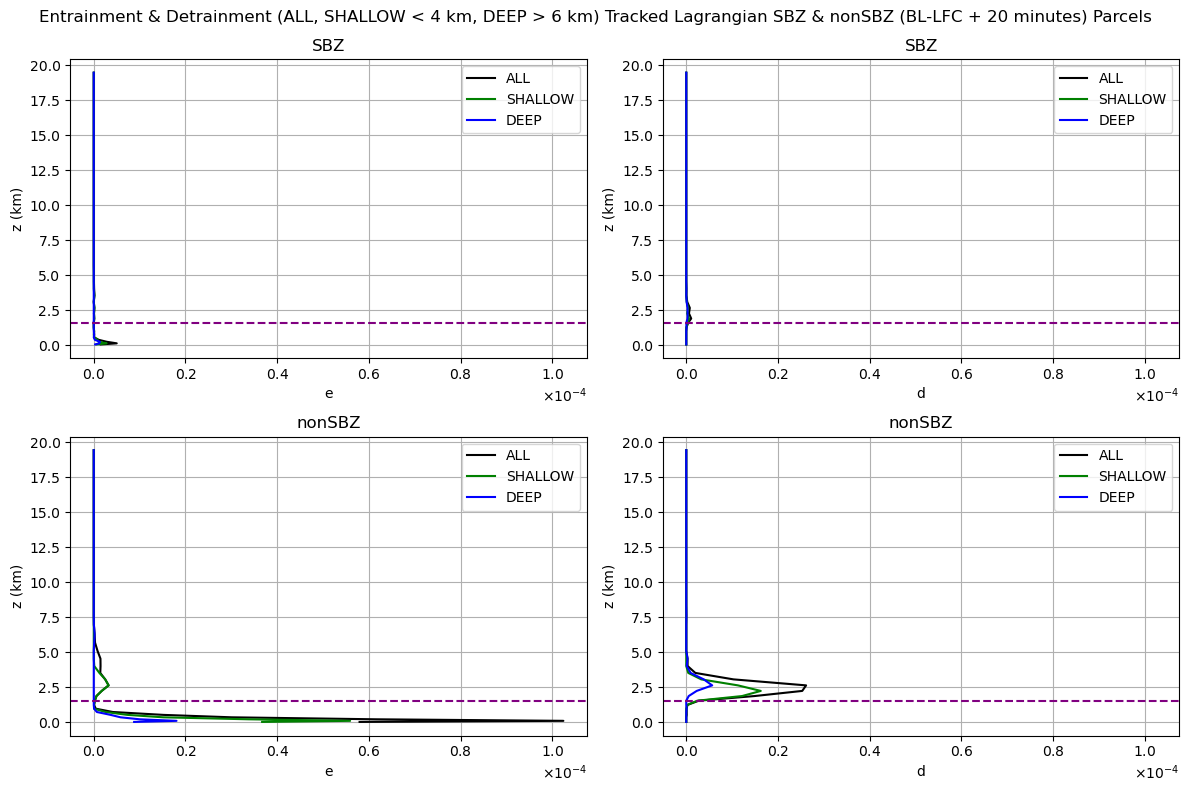

In [77]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

#MAKING DETRAINMENT VALUES POSITIVE
ALL_d[:,0]*=-1;SHALLOW_d[:,0]*=-1;DEEP_d[:,0]*=-1
nonSBZ_ALL_d[:,0]*=-1;nonSBZ_SHALLOW_d[:,0]*=-1;nonSBZ_DEEP_d[:,0]*=-1

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (ALL_e, SHALLOW_e, DEEP_e, 'e', 'SBZ'),
    (ALL_d, SHALLOW_d, DEEP_d, 'd', 'SBZ'),
    (nonSBZ_ALL_e, nonSBZ_SHALLOW_e, nonSBZ_DEEP_e, 'e', 'nonSBZ'),
    (nonSBZ_ALL_d, nonSBZ_SHALLOW_d, nonSBZ_DEEP_d, 'd', 'nonSBZ'),
]

#MINMAX FOR XLIM
min_max_values = [(arr[:, 0].min(), arr[:, 0].max()) for arr, *_ in profiles]
min_max_values=[(min(val[0] for val in min_max_values)),(max(val[1] for val in min_max_values))]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
    globals()[f'ax{i+1}'] = fig.add_subplot(gs[i])  # Dynamically create ax1, ax2, ax3, ...
    ax = globals()[f'ax{i+1}']

    
    # # Compute the averaged profile
    # ALL_profile = averaged_profiles(ALL_profile_array)
    # SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    # DEEP_profile = averaged_profiles(DEEP_profile_array)
    ALL_profile=ALL_profile_array.copy()
    SHALLOW_profile=SHALLOW_profile_array.copy()
    DEEP_profile=DEEP_profile_array.copy()
    
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, -1],color='black',label='ALL')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1],color='green',label='SHALLOW')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1],color='blue',label='DEEP')
    ax.set_xlabel(xlabel)
    ax.set_title(CLlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    ax.legend()
# legend_ax = fig.add_subplot(gs[0, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)


#FIXING AXES
fix_x_limits([ax1,ax2,ax3,ax4])
fix_y_limits([ax1,ax2,ax3,ax4])

#ACCESSORIES
plt.suptitle('Entrainment & Detrainment (ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian SBZ & nonSBZ (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MEAN LFC
# axs = fig.get_axes()
# ax1, ax2, ax3, ax4= axs
# for axis in [ax1,ax2]:
#     axis.axhline(np.mean((mean_LFC(ALL_SBZ_out_nz),mean_LFC(SHALLOW_SBZ_out_nz),
#                           mean_LFC(DEEP_SBZ_out_nz))),color='blue',linestyle='dashed',linewidth=1.2)
# for axis in [ax3,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_nonSBZ_out_nz),mean_LFC(SHALLOW_nonSBZ_out_nz),
#                           mean_LFC(DEEP_nonSBZ_out_nz))),color='blue',linestyle='dashed',linewidth=1.2)

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4= axs
for axis in [ax1,ax2,ax3,ax4]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3,ax4])

(-0.00010339915242289279, 0.00010868367342675188)
(-0.9395961281843483, 20.41351872170344)


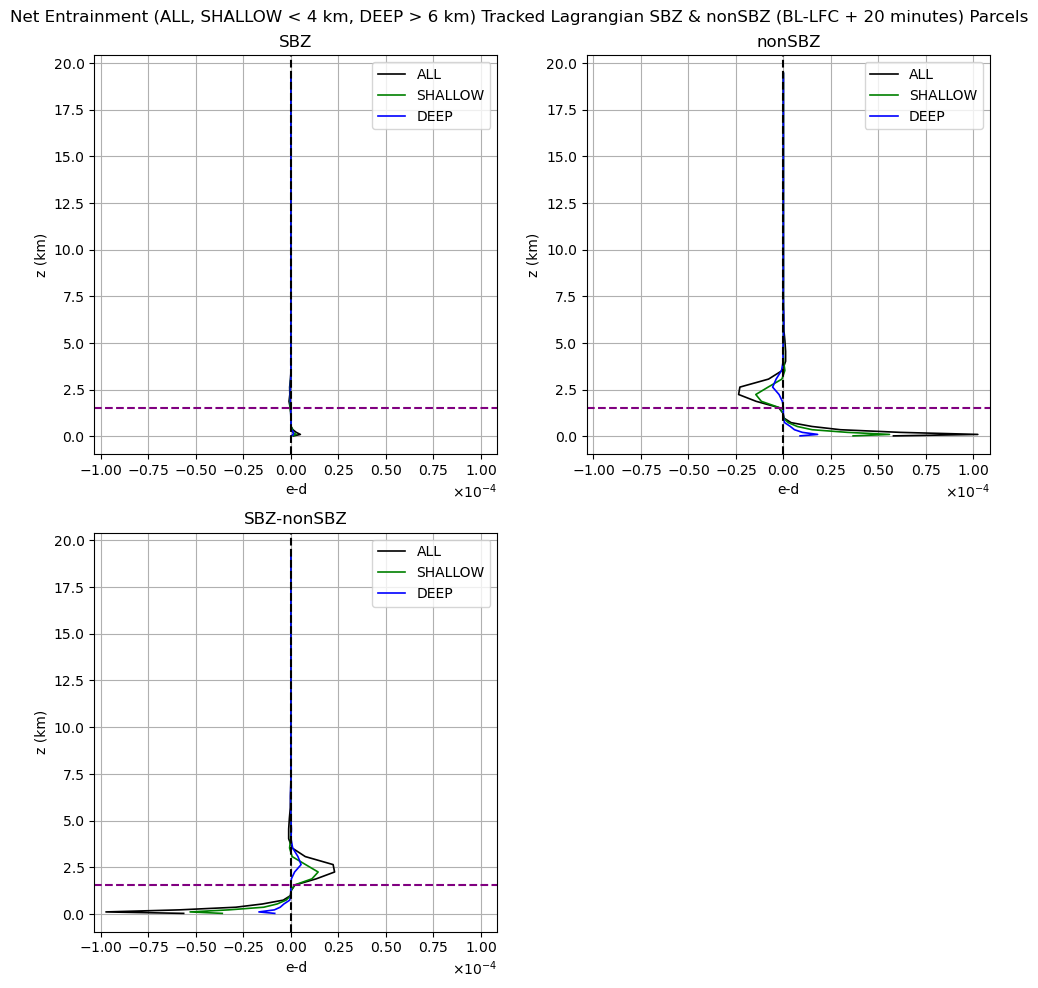

In [78]:
#NET ENTRAINMENT

xlims=[] #FIXING XAXIS
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# List of profile arrays and their corresponding labels and x-axis titles

ALL_net=ALL_e.copy(); ALL_net[:,0]-=ALL_d[:,0]
SHALLOW_net=SHALLOW_e.copy(); SHALLOW_net[:,0]-=SHALLOW_d[:,0]
DEEP_net=DEEP_e.copy(); DEEP_net[:,0]-=DEEP_d[:,0]

nonSBZ_ALL_net=nonSBZ_ALL_e.copy(); nonSBZ_ALL_net[:,0]-=nonSBZ_ALL_d[:,0]
nonSBZ_SHALLOW_net=nonSBZ_SHALLOW_e.copy(); nonSBZ_SHALLOW_net[:,0]-=nonSBZ_SHALLOW_d[:,0]
nonSBZ_DEEP_net=nonSBZ_DEEP_e.copy(); nonSBZ_DEEP_net[:,0]-=nonSBZ_DEEP_d[:,0]

ALL_SBZnonSBZ=ALL_net.copy(); ALL_SBZnonSBZ[:,0]-=nonSBZ_ALL_net[:,0]
SHALLOW_SBZnonSBZ=SHALLOW_net.copy(); SHALLOW_SBZnonSBZ[:,0]-=nonSBZ_SHALLOW_net[:,0]
DEEP_SBZnonSBZ=DEEP_net.copy(); DEEP_SBZnonSBZ[:,0]-=nonSBZ_DEEP_net[:,0]


profiles = [
    (ALL_net, SHALLOW_net, DEEP_net, 'e-d', 'SBZ'),
    (nonSBZ_ALL_net, nonSBZ_SHALLOW_net, nonSBZ_DEEP_net, 'e-d', 'nonSBZ'),
    (ALL_SBZnonSBZ, SHALLOW_SBZnonSBZ, DEEP_SBZnonSBZ, 'e-d', 'SBZ-nonSBZ')
]

#MINMAX FOR XLIM
min_max_values = [(arr[:, 0].min(), arr[:, 0].max()) for arr, *_ in profiles]
min_max_values=[(min(val[0] for val in min_max_values)),(max(val[1] for val in min_max_values))]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
    globals()[f'ax{i+1}'] = fig.add_subplot(gs[i])  # Dynamically create ax1, ax2, ax3, ...
    ax = globals()[f'ax{i+1}']

    
    # # Compute the averaged profile
    # ALL_profile = averaged_profiles(ALL_profile_array)
    # SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    # DEEP_profile = averaged_profiles(DEEP_profile_array)
    ALL_profile=ALL_profile_array.copy()
    SHALLOW_profile=SHALLOW_profile_array.copy()
    DEEP_profile=DEEP_profile_array.copy()
    
    
    # Plot the profile

    #linewidth
    if i == 2: 
        lw=1.2
    else: lw=1.2
        
    ax.plot(ALL_profile[:, 0], ALL_profile[:, -1],color='black',label='ALL',lw=lw)
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1],color='green',label='SHALLOW',lw=lw)
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1],color='blue',label='DEEP',lw=lw)

    ax.axvline(0,color='k',linestyle='dashed')
    ax.set_xlabel(xlabel)
    ax.set_title(CLlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)
    

#LEGEND
    ax.legend()
# legend_ax = fig.add_subplot(gs[0, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#FIXING AXES
axs = fig.get_axes(); ax1,ax2,ax3=axs
fix_x_limits([ax1,ax2,ax3])
fix_y_limits([ax1,ax2,ax3])

#ACCESSORIES
plt.suptitle('Net Entrainment (ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian SBZ & nonSBZ (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MEAN LFC
# axs = fig.get_axes()
# ax1, ax2, ax3 = axs
# for axis in [ax1]:
#     axis.axhline(np.mean((mean_LFC(ALL_SBZ_out_nz),mean_LFC(SHALLOW_SBZ_out_nz),
#                           mean_LFC(DEEP_SBZ_out_nz))),color='blue',linestyle='dashed',linewidth=1.2)
# for axis in [ax2]:
#     axis.axhline(np.mean((mean_LFC(ALL_nonSBZ_out_nz),mean_LFC(SHALLOW_nonSBZ_out_nz),
#                           mean_LFC(DEEP_nonSBZ_out_nz))),color='blue',linestyle='dashed',linewidth=1.2)
# for axis in [ax3]:
#     axis.axhline(np.mean((mean_LFC(ALL_SBZ_out_nz),mean_LFC(SHALLOW_SBZ_out_nz),
#                           mean_LFC(DEEP_SBZ_out_nz),mean_LFC(ALL_nonSBZ_out_nz),mean_LFC(SHALLOW_nonSBZ_out_nz),
#                           mean_LFC(DEEP_nonSBZ_out_nz))),color='blue',linestyle='dashed',linewidth=1.2)

#MEAN CLOUD BASE
axs = fig.get_axes(); ax1,ax2,ax3=axs
for axis in [ax1,ax2,ax3]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3])